In [65]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

In [66]:
# Load data
data = []
with open('kg.txt', 'r') as f:
    for line in f:
        parts = line.strip().split()
        drug, protein, interaction = int(parts[0]), int(parts[1]), int(parts[2])
        data.append({'drug': drug, 'protein': protein, 'interaction': interaction})

df = pd.DataFrame(data)
df

,drug,protein,interaction
0,0,0,1
1,1,0,1
2,2,1,2
3,3,2,2
4,3,1,2
...,...,...,...
10710,1171,1639,3
10711,1171,565,3
10712,494,512,3
10713,1176,1643,1


In [67]:
# Sample the data (change sample size as needed)
sample_size = 100
df_sample = df.sample(n=min(sample_size, len(df)))

print(f"Visualizing {len(df_sample)} interactions")

# Create bipartite graph
G = nx.Graph()

# Add nodes with bipartite attribute
drugs = df_sample['drug'].unique()
proteins = df_sample['protein'].unique()

G.add_nodes_from([f"D{d}" for d in drugs], bipartite=0)
G.add_nodes_from([f"P{p}" for p in proteins], bipartite=1)

# Add edges with interaction type
for _, row in df_sample.iterrows():
    G.add_edge(f"D{row['drug']}", f"P{row['protein']}", interaction=row['interaction'])

# Separate nodes by bipartite set
drug_nodes = [n for n in G.nodes() if n.startswith('D')]
protein_nodes = [n for n in G.nodes() if n.startswith('P')]

# Create bipartite layout
pos = {}
drug_y = np.linspace(0, 10, len(drug_nodes))
protein_y = np.linspace(0, 10, len(protein_nodes))

for i, node in enumerate(sorted(drug_nodes)):
    pos[node] = (0, drug_y[i])
    
for i, node in enumerate(sorted(protein_nodes)):
    pos[node] = (5, protein_y[i])

# Get unique interaction types
interactions = df_sample['interaction'].unique()
n_interactions = len(interactions)

# Color map for interactions
colors = plt.cm.Set3(np.linspace(0, 1, n_interactions))
interaction_colors = {inter: colors[i] for i, inter in enumerate(interactions)}

Visualizing 100 interactions


Saved as drug_protein_bipartite.pdf


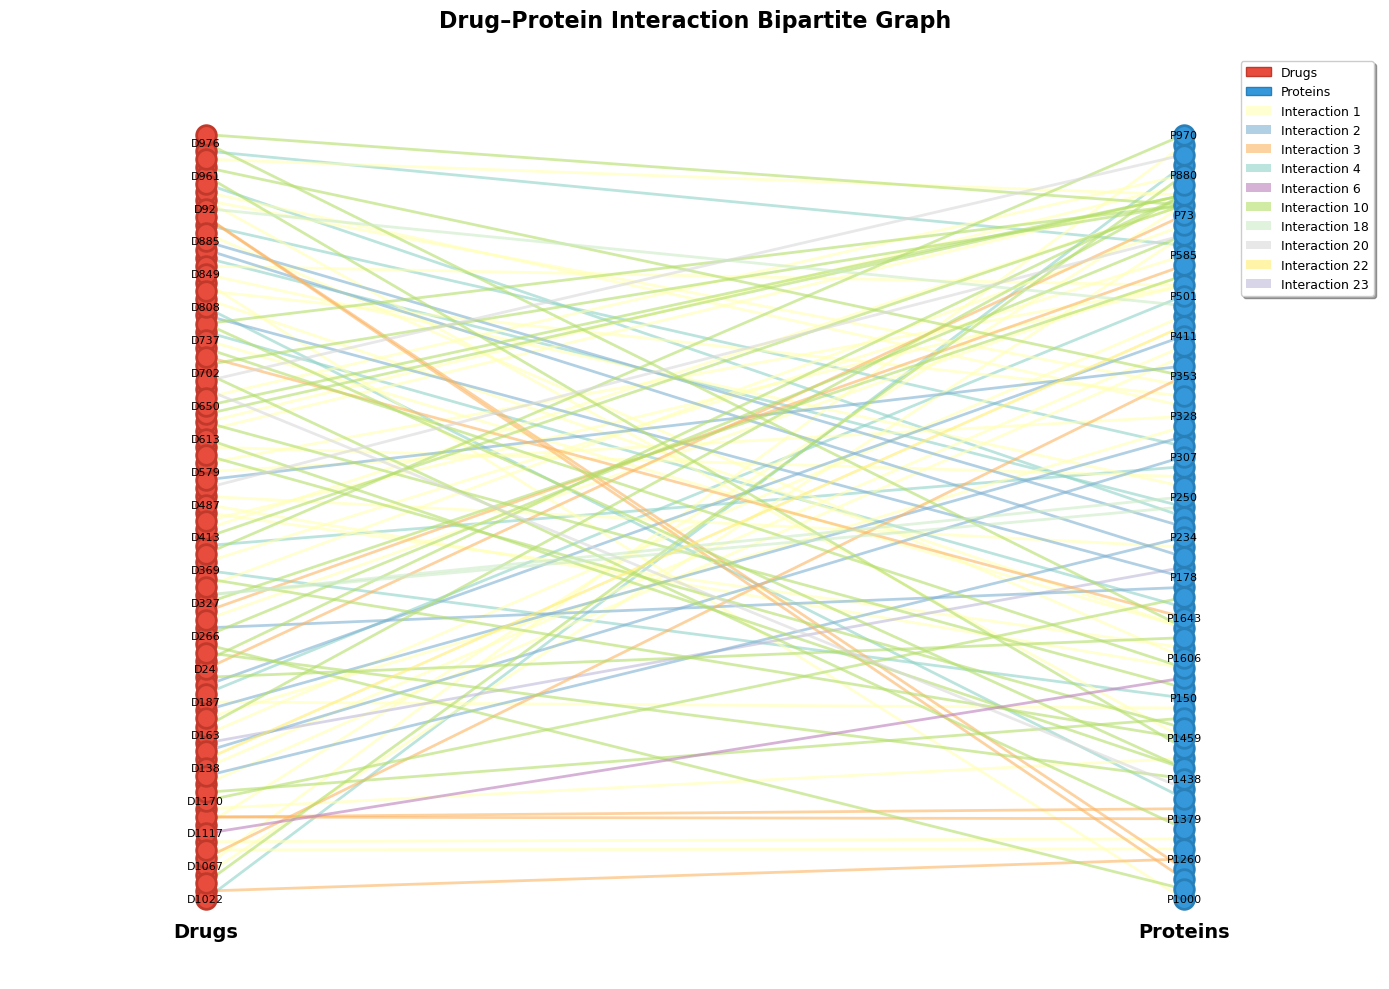

In [68]:

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Draw edges by interaction type
for interaction in interactions:
    edges = [(f"D{row['drug']}", f"P{row['protein']}") 
             for _, row in df_sample[df_sample['interaction'] == interaction].iterrows()]
    nx.draw_networkx_edges(G, pos, edgelist=edges, 
                          edge_color=[interaction_colors[interaction]], 
                          width=2, alpha=0.6, ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=drug_nodes, 
                      node_color='#e74c3c', node_size=200, 
                      edgecolors='#c0392b', linewidths=2, ax=ax)

nx.draw_networkx_nodes(G, pos, nodelist=protein_nodes, 
                      node_color='#3498db', node_size=200, 
                      edgecolors='#2980b9', linewidths=2, ax=ax)

# Add labels to some nodes (to avoid clutter)
label_every = max(1, len(drug_nodes) // 20)
drug_labels = {node: node for i, node in enumerate(sorted(drug_nodes)) if i % label_every == 0}
protein_labels = {node: node for i, node in enumerate(sorted(protein_nodes)) if i % label_every == 0}

nx.draw_networkx_labels(G, pos, drug_labels, font_size=8, ax=ax)
nx.draw_networkx_labels(G, pos, protein_labels, font_size=8, ax=ax)

# Styling
ax.set_title('Drug–Protein Interaction Bipartite Graph', 
             fontsize=16, fontweight='bold', pad=20)
ax.text(0, -0.5, 'Drugs', ha='center', fontsize=14, fontweight='bold')
ax.text(5, -0.5, 'Proteins', ha='center', fontsize=14, fontweight='bold')

# Legend
legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='#c0392b', label='Drugs'),
    Patch(facecolor='#3498db', edgecolor='#2980b9', label='Proteins')
]

# Add interaction type legend (show only first 10 to avoid clutter)
for i, interaction in enumerate(sorted(interactions)[:10]):
    legend_elements.append(
        Patch(facecolor=interaction_colors[interaction], 
              label=f'Interaction {interaction}', alpha=0.6)
    )

ax.legend(handles=legend_elements, loc='upper right', 
         frameon=True, fancybox=True, shadow=True, fontsize=9)

ax.axis('off')
ax.set_xlim(-1, 6)

plt.tight_layout()

# Save as PDF
plt.savefig('drug_protein_bipartite.pdf', dpi=300, bbox_inches='tight')
print("Saved as drug_protein_bipartite.pdf")

plt.show()